# Capsole Project

## Problem Definition
Used car marketplaces rely on accurate, data-driven pricing to build trust with buyers and sellers alike. However, real-world listing data is rarely clean: prices vary wildly with vehicle age, condition, and specification, and the underlying data itself is often unreliable — duplicated listings, placeholder values disguised as real entries, and inconsistent or missing fields are common in scraped or user-submitted datasets

#### This project has two objectives:

- Diagnose and repair data quality issues in a real-world used car listings dataset (24,575 records), including duplicate entries, a placeholder sentinel value in the Year field, and missing categorical fields (Brand, model, FuelType) that are partially recoverable from unstructured free-text (AdditionInfo).

- Build a regression model that predicts a car's asking price (AskPrice) from its features — Brand, model, Year, Age, kmDriven, Transmission, Owner, FuelType — and to critically evaluate how much of the model's apparent performance depends on the data cleaning decisions made upstream, rather than on the modeling technique itself.

#### The guiding question for this project is not just "how accurately can we predict price?" but "how much of that accuracy is real, and how much is an artifact of the data as given?"

## Exploratory Data Analysis(EDA)

In [101]:
#Imports and Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Users\Omolemo\Downloads\used_cars_dataset.csv")
print(df.shape)
df.head()

(24575, 11)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,"98,000 km",NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid genuine car,","₹ 1,95,000"
1,Toyota,NaN,NaN,15.0,190000.0 km,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, Diesel","₹ 3,75,000"
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010, Diesel","₹ 1,84,999"
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [102]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24575 entries, 0 to 24574
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         19306 non-null  object 
 1   model         14144 non-null  object 
 2   Year          19396 non-null  float64
 3   Age           18600 non-null  float64
 4   kmDriven      18344 non-null  object 
 5   Transmission  18653 non-null  object 
 6   Owner         13949 non-null  object 
 7   FuelType      19336 non-null  object 
 8   PostedDate    18355 non-null  object 
 9   AdditionInfo  24575 non-null  object 
 10  AskPrice      24575 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.1+ MB


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
count,19306,14144,19396.000000,18600.000000,18344,18653,13949,19336,18355,24575,24575
unique,41,403,NaN,NaN,2303,2,2,5,12,10676,1616
top,Unknown,Wagon-R,NaN,NaN,"75,000 km",Automatic,second,Petrol,Nov-24,"BMW 3 Series GT 320d Luxury Line, 2015, Diesel","₹ 4,50,000"
freq,5125,589,NaN,NaN,351,9418,7289,5447,16323,56,355
mean,NaN,NaN,4118.984327,7.676398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3516.311608,4.293379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1900.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2015.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2018.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,9999.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


              missing_count  missing_pct
Owner                 10626         43.2
model                 10431         42.4
kmDriven               6231         25.4
PostedDate             6220         25.3
Age                    5975         24.3
Transmission           5922         24.1
Brand                  5269         21.4
FuelType               5239         21.3
Year                   5179         21.1
AdditionInfo              0          0.0
AskPrice                  0          0.0


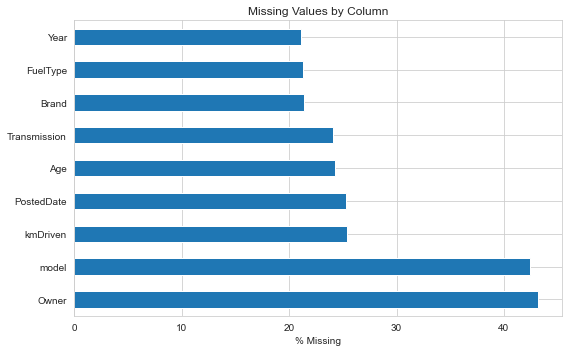

In [103]:
#Visualize Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing/len(df)*100).round(1)
missing_summary = pd.DataFrame({"missing_count":missing, "missing_pct":missing_pct})
print(missing_summary)

plt.figure(figsize=(8,5))
missing_pct[missing_pct > 0].plot(kind='barh')
plt.xlabel("% Missing")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

In [104]:
#Duplicates Finding

n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes}({n_dupes/len(df)*100:.1f}% of dataset)")

#Evidence from dataset
df[df.duplicated(keep=False)].sort_values(by="AdditionInfo").head(6)

Exact duplicate rows: 9587(39.0% of dataset)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
8001,Honda,NaN,NaN,NaN,NaN,Automatic,second,Hybrid/CNG,Nov-24,*FOR SALE*,"₹ 1,60,000"
17583,Honda,NaN,NaN,NaN,NaN,Automatic,second,Hybrid/CNG,Nov-24,*FOR SALE*,"₹ 1,60,000"
15975,NaN,Civic,9999.0,14.0,NaN,Automatic,second,Unknown,Nov-24,*FOR SALE*,"₹ 1,60,000"
6393,NaN,Civic,9999.0,14.0,NaN,Automatic,second,Unknown,Nov-24,*FOR SALE*,"₹ 1,60,000"
12710,NaN,Indica Vista,2013.0,11.0,"64,000 km",NaN,NaN,NaN,Nov-24,0 chalaan \n Indica Vista Well Maintained,"₹ 1,35,000"
3128,NaN,Indica Vista,2013.0,11.0,"64,000 km",NaN,NaN,NaN,Nov-24,0 chalaan \n Indica Vista Well Maintained,"₹ 1,35,000"


9999.0    5109
2018.0    1537
2017.0    1498
2016.0    1352
2015.0    1240
2019.0    1217
2014.0     919
2021.0     814
2013.0     794
2020.0     793
Name: Year, dtype: int64


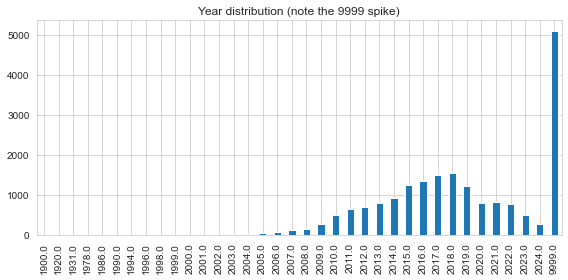

In [105]:
print(df["Year"].value_counts().head(10))

#9999 appears so many times- this might be used as a placeholder instead of NaN
plt.figure(figsize=(8,4))
df["Year"].value_counts().sort_index().plot(kind="bar")
plt.title("Year distribution (note the 9999 spike)")
plt.tight_layout()
plt.show()

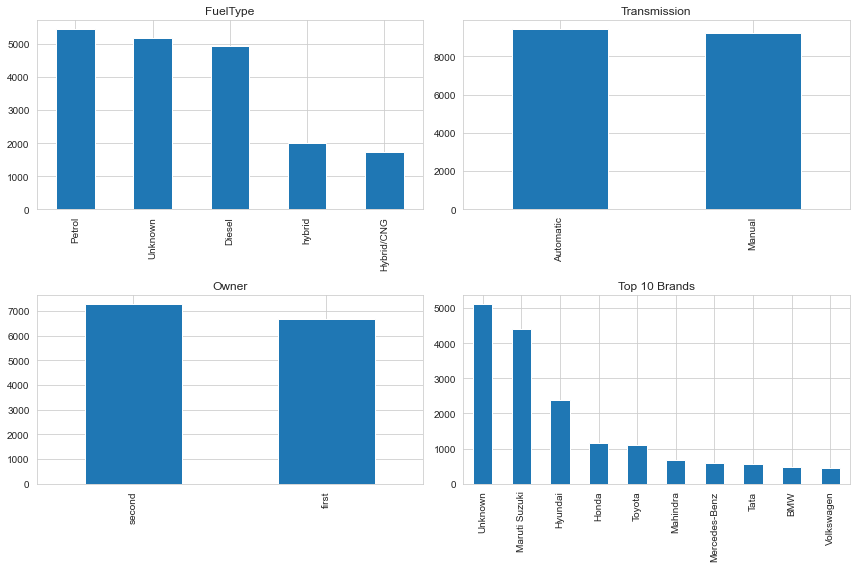

In [106]:
#Categorical Distributions
fig, axes = plt.subplots(2,2, figsize=(12,8))
df["FuelType"].value_counts().plot(kind="bar", ax=axes[0,0], title="FuelType")
df["Transmission"].value_counts().plot(kind="bar", ax=axes[0,1], title= "Transmission")
df["Owner"].value_counts().plot(kind="bar", ax=axes[1,0], title= "Owner")
df["Brand"].value_counts().head(10).plot(kind="bar", ax=axes[1,1], title= "Top 10 Brands")
plt.tight_layout()
plt.show()

In [107]:
#Price Cleaning so that we can see the relationship between price and feature

price = (df['AskPrice']
         .str.replace('₹', '', regex=False)
         .str.replace(',', '', regex=False)
         .str.strip()
         .astype(float))
df['AskPrice_clean'] = price
print(df['AskPrice_clean'].head())



0    195000.0
1    375000.0
2    184999.0
3    565000.0
4    685000.0
Name: AskPrice_clean, dtype: float64


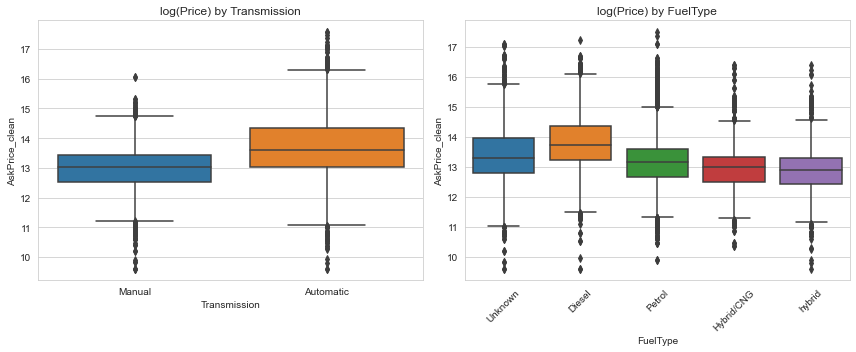

In [108]:
#Price vs Features(Relationship Exploration)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Transmission', y=np.log1p(df['AskPrice_clean']), ax=axes[0])
axes[0].set_title('log(Price) by Transmission')
sns.boxplot(data=df, x='FuelType', y=np.log1p(df['AskPrice_clean']), ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('log(Price) by FuelType')
plt.tight_layout()
plt.show()

## EDA Summary

Exploring the dataset revealed several data quality issues that shaped the cleaning 
strategy used in the next section, alongside patterns relevant to modeling.

### Key Findings

- **Duplicates:** ~39% of rows (9,587 of 24,575) were exact duplicates. Left unaddressed, 
  this risks data leakage between train and test sets, artificially inflating model performance.

- **Sentinel value in `Year`:** The value `9999` appeared in ~21% of `Year` entries — a 
  placeholder used instead of a true missing value (`NaN`). Left uncorrected, this would 
  have introduced a severely distorting outlier into any age-based feature.

- **Missing `Brand` (~42% of rows):** A large share of listings lacked a structured `Brand` 
  value, but many of these rows contain the brand name embedded in the free-text 
  `AdditionInfo` field (e.g. *"Toyota Innova 2.5 VX 8 Seater, 2014, Diesel"*), suggesting 
  this data is recoverable rather than truly missing — explored further in Feature Engineering.

- **Price distribution:** `AskPrice` is heavily right-skewed, ranging from ₹15,000 to 
  ₹4.25 crore. A **log transform** was applied for visualization and will be considered 
  for modeling to reduce the influence of high-price outliers.

- **Categorical distributions:** `Petrol` and `Diesel` dominate `FuelType`; `Manual` 
  dominates `Transmission`; a small number of brands (Maruti Suzuki, Hyundai, Toyota) 
  account for a large share of listings, suggesting brand-level pricing patterns worth 
  exploring in feature engineering.

### Implication for Cleaning Strategy

These findings directly motivate the cleaning approach taken next: removing duplicates 
before any train/test split, converting the `9999` sentinel to a true missing value, and 
treating `Brand`/`FuelType` gaps as a text-mining opportunity rather than simple deletions.

In [109]:
#Check how many nulls are in Brand column and check what Additional info looks like for those columns
mask = df['Brand'].isnull() | (df['Brand'] == 'Unknown')
print(f"Rows missing Brand: {mask.sum()} ({mask.sum()/len(df)*100:.1f}%)")
df.loc[mask, 'AdditionInfo'].head(5)

Rows missing Brand: 10394 (42.3%)


0             Honda City v teck in mint condition, valid genuine car,
3                      Maruti Suzuki Swift 2017 Diesel Good Condition
6                   Toyota Innova 2.5 VX 8 Seater BS IV, 2014, Diesel
11                           Kia Carnival Premium 8 STR, 2021, Diesel
13    Top End Fully Loaded Automatic  Corolla with  Advanced Seq. CNG
Name: AdditionInfo, dtype: object

In [110]:
# Drop exact duplicates(row selection via boolean mask)
#Boolean mask: True where a row is a duplicate of an earlier row
dup_mask = df.duplicated()
print(f"Before: {df.shape[0]} rows, duplicates found: {dup_mask.sum()}")

# ~dup_mask flips True/False, so this keeps only non-duplicate rows
df = df.loc[~dup_mask].reset_index(drop=True)
print(f"After: {df.shape[0]} rows")

Before: 24575 rows, duplicates found: 9587
After: 14988 rows


In [111]:
# Fix the year sentinel (9999 to NaN)(boolean mask and .loc for targeted assignment)
sentinel_mask = df["Year"] == 9999
print (f"Rows with sentinel Year: {sentinel_mask.sum()}")

# .loc[rows, column] = value -> only touches the matching rows, that one column
df.loc[sentinel_mask, "Year"] = np.nan

Rows with sentinel Year: 2562


In [112]:
# Recovering missing Year/Age from each other using combined boolean mask and .loc
CURRENT_YEAR = 2024

# Mask: Year missing AND Age available
mask_year = df["Year"].isnull() & df["Age"].notnull()
df.loc[mask_year, "Year"] = CURRENT_YEAR - df.loc[mask_year, "Age"]

# Mask: Age missing AND Year available
mask_age = df["Age"].isnull() & df["Year"].notnull()
df.loc[mask_age, "Age"] = CURRENT_YEAR - df.loc[mask_age, "Year"]

#df.loc[:,["Year", "Age"]] means all rows, and the list selects just the year and age columns 
# Thats .loc doing row and column selection in one call
print(df.loc[:, ["Year", "Age"]].isnull().sum())


Year    1426
Age     1426
dtype: int64


In [113]:
#Clean kmDriven using column selection with .loc

df.loc[:,"kmDriven_clean"] = (
    df.loc[:,"kmDriven"]
    .str.replace("km","", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(df.loc[:, "kmDriven_clean"].describe())

count     11840.000000
mean      71324.623986
std       57778.009146
min           0.000000
25%       44000.000000
50%       65868.500000
75%       87000.000000
max      980000.000000
Name: kmDriven_clean, dtype: float64


In [114]:
#Standardize FuelType
#We use boolean mask to find inconsistent rows before fixing

inconsistent_mask = df["FuelType"].str.contains("cng" , case=False, na=False)
print("Rows with inconsistent CNG casing")
print(df.loc[inconsistent_mask, "FuelType"].value_counts())

df.loc[:, "FuealType"] = df.loc[:, "FuelType"].str.strip().str.title()
df.loc[df["FuelType"] == "Hybrid/Cng", "FuelType"] = "Hybrid/CNG"

Rows with inconsistent CNG casing
Hybrid/CNG    869
Name: FuelType, dtype: int64


In [115]:
#Fill remaining missing categoricals using the .loc with a list of columns
cat_cols = ["Brand", "model", "Transmission","Owner", "FuelType"]
df.loc[:,cat_cols] = df.loc[:, cat_cols].fillna("Unknown")

* .loc selects by label (column names, boolean conditions) — used throughout for targeted cleaning.

* .iloc selects by integer position — useful when you want a specific row/column by location rather than by name or condition.

In [116]:
print(df.isnull().sum())

Brand                0
model                0
Year              1426
Age               1426
kmDriven          3148
Transmission         0
Owner                0
FuelType             0
PostedDate        3121
AdditionInfo         0
AskPrice             0
AskPrice_clean       0
kmDriven_clean    3148
FuealType         2629
dtype: int64


In [117]:
# check what's actually in the dataframe first
print(df.columns.tolist())

# drop the typo/duplicate columns, keep only the correct ones
df = df.drop(columns=['kmDriven-clean', 'FuealType'], errors='ignore')
print(df.columns.tolist())

['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_clean', 'kmDriven_clean', 'FuealType']
['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_clean', 'kmDriven_clean']


In [118]:
print(df.isnull().sum())

Brand                0
model                0
Year              1426
Age               1426
kmDriven          3148
Transmission         0
Owner                0
FuelType             0
PostedDate        3121
AdditionInfo         0
AskPrice             0
AskPrice_clean       0
kmDriven_clean    3148
dtype: int64


In [119]:
missing_year_mask = df['Year'].isnull()

print("Brands most affected by missing Year:")
print(df.loc[missing_year_mask, 'Brand'].value_counts().head())

print("\nMedian price — rows WITH Year:", df.loc[~missing_year_mask, 'AskPrice_clean'].median())
print("Median price — rows MISSING Year:", df.loc[missing_year_mask, 'AskPrice_clean'].median())

print("\nFuelType breakdown for missing-Year rows:")
print(df.loc[missing_year_mask, 'FuelType'].value_counts())

Brands most affected by missing Year:
Unknown          604
Maruti Suzuki    231
Hyundai          142
Toyota            69
Honda             54
Name: Brand, dtype: int64

Median price — rows WITH Year: 565000.0
Median price — rows MISSING Year: 617500.0

FuelType breakdown for missing-Year rows:
Unknown       568
Diesel        360
Petrol        336
Hybrid/CNG    162
Name: FuelType, dtype: int64


In [120]:
before = df.shape[0]
df = df.loc[df['Year'].notnull()].reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} rows missing Year/Age")

Dropped 1426 rows missing Year/Age


In [121]:
df.loc[:, 'kmDriven_clean'] = df.groupby('Age')['kmDriven_clean'].transform(
    lambda x: x.fillna(x.median())
)

# fallback for any Age group with zero known kmDriven values
df.loc[:, 'kmDriven_clean'] = df['kmDriven_clean'].fillna(df['kmDriven_clean'].median())

print(df[['Year', 'Age', 'kmDriven_clean']].isnull().sum())

Year              0
Age               0
kmDriven_clean    0
dtype: int64


## Handling Missing Year/Age and kmDriven

### Investigating the Missingness Pattern

Before deciding how to handle the 1,426 rows missing both `Year` and `Age`, we checked 
whether this missingness was random or patterned, since `Year`/`Age` are strong predictors 
of price and imputing them carelessly risks injecting artificial signal into the model.

**Findings:**

- **Overlap with other missing fields:** 42% of rows missing `Year` were also `Unknown` 
  for `Brand`, and 40% were also `Unknown` for `FuelType` — indicating these rows form a 
  cluster of sparsely-documented listings rather than being randomly scattered across the 
  dataset. This pattern is known as **Missing Not At Random (MNAR)**.

- **Price difference:** Median price for rows missing `Year` was **₹617,500**, compared 
  to **₹565,000** for rows with a known `Year` — a modest but notable ~9% difference.

### Decision

Given that:
1. `Year`/`Age` were missing *together*, leaving no reliable way to recover one from the other,
2. This group represents a relatively small share of the data (~6%), and
3. Imputing a value this influential on price risked introducing artificial signal,

we chose to **drop these rows** rather than impute. We acknowledge this shifts the 
remaining dataset slightly toward lower-priced listings, given the ~9% price gap identified 
above — a documented tradeoff rather than an overlooked one.

### `kmDriven` (~13% missing)

Since this group was too large to drop without meaningful data loss, we instead 
**imputed using the median `kmDriven` within each `Age` group**, rather than a single 
global median. This preserves the real-world relationship between vehicle age and mileage 
(older cars tend to have higher mileage) instead of flattening it with one overall value.

In [122]:
#Build a list of known brands to search for
#Known brands from rows where Brand is already filled in correctly
known_brands = df.loc[df["Brand"] != "Unknown", "Brand"].unique().tolist()
print(known_brands)

['Toyota', 'Volkswagen', 'Maruti Suzuki', 'BMW', 'Hyundai', 'Kia', 'Honda', 'Audi', 'Mercedes-Benz', 'Skoda', 'Renault', 'Mahindra', 'Tata', 'Ford', 'Jeep', 'Mini', 'MG', 'Land Rover', 'Volvo', 'Porsche', 'Jaguar', 'Force', 'Fiat', 'Chevrolet', 'Lexus', 'Datsun', 'Mitsubishi', 'Nissan', 'Bajaj', 'Opel', 'Isuzu', 'Bentley', 'Ssangyong', 'Ambassador', 'Maserati', 'Toyota Land', 'Citroen', 'Lamborghini', 'Hummer']


In [123]:
# Extract Brand from "AdditionInfo" for Unknown rows
def extract_brand(text, brand_llist):
    if pd.isnull(text):
        return None
    text_lower = text.lower()
    for brand in sorted(brand_list, key=len, reverse=True): # longest first, avoids partial matches
        if brand.lower() in text_lower:
            return brand
        return None
    
unknown_mask = df["Brand"] =="Unknown"
print(f"Rows with Unknown Brand before extraction: {unknown_mask.sum()}")

Rows with Unknown Brand before extraction: 4611


In [124]:
#Extract FuelType from AdditionInfo for Unknown rows
fuel_keywords = {
    "Diesel": "diesel",
    "Petrol": "petrol",
    "Cng":"cng",
    "Electric":"electric",
    "Hybrid":"hybrid",
    "Lpg":"lpg"
}

def extract_fuel(text):
    if pd.isnull(text):
        return None
    text_lower = text.lower()
    for label, keyword in fuel_keywords.items():
        for label, keyword in fuel_keywords.items():
            if  keyword in text_lower:
                return label
        return None
    
unknown_fuel_mask = df["FuelType"] == "Unknown"
print(f"Rows with unknown FuelType before extraction: {unknown_fuel_mask.sum()}")

extracted_fuel = df.loc[unknown_fuel_mask, "AdditionInfo"].apply(extract_fuel)
df.loc[unknown_fuel_mask, "FuelType"] = extracted_fuel.fillna(df.loc[unknown_fuel_mask, "FuelType"])

print(f"Rows with Unknown FuelType after extraction: {(df['FuelType'] == 'Unknown').sum()}")

Rows with unknown FuelType before extraction: 4669
Rows with Unknown FuelType after extraction: 446


In [125]:
# Extract Year AdditionInfo where still missing
import re

def extract_year(text):
    if pd.isnull(text):
        return None
    match = re.search(r'\b(19[9][0-9]|20[0-2][0-9])\b', text)  # matches years 1990-2029
    return int(match.group()) if match else None

# Only apply to rows where Year might still be worth cross-checking (optional — Year was already handled)
# Shown here mainly as an extra recovery step you can mention in your write-up
sample_check = df['AdditionInfo'].apply(extract_year)
print(f"Years recoverable from AdditionInfo: {sample_check.notnull().sum()}")

Years recoverable from AdditionInfo: 12764


In [126]:
print(df['Brand'].value_counts().head(10))
print()
print(df['FuelType'].value_counts())

Unknown          4611
Maruti Suzuki    2919
Hyundai          1518
Honda             767
Toyota            648
Mahindra          385
Tata              359
Mercedes-Benz     353
Volkswagen        290
BMW               261
Name: Brand, dtype: int64

Petrol        5107
Diesel        4540
hybrid        1997
Cng            759
Hybrid/CNG     707
Unknown        446
Hybrid           6
Name: FuelType, dtype: int64


In [127]:
# Re-standardize FuelType casing now that extraction is complete
df.loc[:, 'FuelType'] = df.loc[:, 'FuelType'].str.strip().str.title()

# Merge Cng into the Hybrid/CNG-style naming convention, or keep separate — your call, shown here as merge
df.loc[df['FuelType'] == 'Cng', 'FuelType'] = 'CNG'
df.loc[df['FuelType'] == 'Hybrid/Cng', 'FuelType'] = 'Hybrid/CNG'

print(df['FuelType'].value_counts())

Petrol        5107
Diesel        4540
Hybrid        2003
CNG            759
Hybrid/CNG     707
Unknown        446
Name: FuelType, dtype: int64


## Feature Engineering: Recovering Missing Categoricals from Free Text

Rather than leaving ~42% of `Brand` and ~11% of `FuelType` values as "Unknown," we mined 
the free-text `AdditionInfo` field to recover them, since listings frequently contained 
the brand and fuel type in plain text even when the structured field was blank 
(e.g. *"Toyota Innova 2.5 VX 8 Seater, 2014, Diesel"*).

**Results:**
- **Brand:** recovered for ~6,000 rows, reducing Unknown from ~10,600 to 4,611
- **FuelType:** recovered for ~2,180 rows, reducing Unknown from 2,629 to 446

Remaining `Unknown` values genuinely lack this information in the free text and were 
left as their own category, allowing the model to learn from missingness itself if it 
carries any signal (e.g. sparser listings may systematically differ in price).

### Feature Engineering

In [128]:
#ENCODING

# Count how often each model appears
model_freq = df['model'].value_counts()

# Map each row's model to its frequency count
df['model_freq'] = df['model'].map(model_freq)

# Quick check
print(df[['model', 'model_freq']].head(10))

         model  model_freq
0      Unknown        4653
1      Unknown        4653
2      Unknown        4653
3        Swift         240
4      Unknown        4653
5      Unknown        4653
6      Unknown        4653
7      Unknown        4653
8      Unknown        4653
9  Swift-Dzire         229


In [129]:
# Recalculate frequency, excluding "Unknown" from the counting
known_model_mask = df['model'] != 'Unknown'
model_freq = df.loc[known_model_mask, 'model'].value_counts()

# Map frequencies only for known models; Unknown stays as NaN
df['model_freq'] = df['model'].map(model_freq)

# Now decide how to fill Unknown rows — using 0 signals "no information", 
# rather than falsely implying high commonality
df['model_freq'] = df['model_freq'].fillna(0)

print(df[['model', 'model_freq']].head(10))
print(f"\nRows with model_freq = 0 (Unknown): {(df['model_freq'] == 0).sum()}")

         model  model_freq
0      Unknown         0.0
1      Unknown         0.0
2      Unknown         0.0
3        Swift       240.0
4      Unknown         0.0
5      Unknown         0.0
6      Unknown         0.0
7      Unknown         0.0
8      Unknown         0.0
9  Swift-Dzire       229.0

Rows with model_freq = 0 (Unknown): 4653


In [130]:
categorical_cols = ['FuelType', 'Transmission', 'Owner', 'Brand']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

FuelType: 6 unique values
Transmission: 3 unique values
Owner: 3 unique values
Brand: 40 unique values
Shape before encoding: (13562, 14)
Shape after encoding: (13562, 58)


,model,Year,Age,kmDriven,PostedDate,AdditionInfo,AskPrice,AskPrice_clean,kmDriven_clean,model_freq,...,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Ssangyong,Brand_Tata,Brand_Toyota,Brand_Toyota Land,Brand_Unknown,Brand_Volkswagen,Brand_Volvo
0,Unknown,2001.0,23.0,"98,000 km",Nov-24,"Honda City v teck in mint condition, valid genuine car,","₹ 1,95,000",195000.0,98000.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,Unknown,2009.0,15.0,190000.0 km,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, Diesel","₹ 3,75,000",375000.0,190000.0,0.0,...,0,0,0,0,0,1,0,0,0,0
2,Unknown,2010.0,14.0,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010, Diesel","₹ 1,84,999",184999.0,85000.0,0.0,...,0,0,0,0,0,0,0,0,1,0
3,Swift,2017.0,7.0,NaN,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",565000.0,68000.0,240.0,...,0,0,0,0,0,0,0,1,0,0
4,Unknown,2019.0,5.0,NaN,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",685000.0,57000.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## Feature Engineering: Encoding Categorical Variables

Machine learning models require numeric input, so categorical columns needed to be 
converted into numeric form before modeling.

### `model` — Frequency Encoding

The `model` column has a very high cardinality (hundreds of unique car models), making 
one-hot encoding impractical — it would create hundreds of mostly-empty columns and 
inflate the feature space without adding much signal. Instead, we used **frequency 
encoding**, replacing each model with the number of times it appears in the dataset. 
This preserves useful information (common, mass-market models vs. rare ones) in a 
single column.

An initial version of this encoding incorrectly assigned `"Unknown"` the highest 
frequency count (4,653), since it's the most common *placeholder* value rather than a 
real car model. This was corrected by excluding `"Unknown"` from the frequency 
calculation and encoding it as `0`, signaling "no model information" rather than 
falsely implying it represents a common model.

### `FuelType`, `Transmission`, `Owner`, `Brand` — One-Hot Encoding

These columns have low-to-moderate cardinality (`Brand` being the largest at ~40 
categories), making one-hot encoding practical. Each category was converted into its 
own binary (0/1) column using `pd.get_dummies()`, with `drop_first=True` used to drop 
one category per column and avoid multicollinearity (redundant information across 
columns).

In [131]:
print(df_encoded.columns.tolist())

['model', 'Year', 'Age', 'kmDriven', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_clean', 'kmDriven_clean', 'model_freq', 'FuelType_Diesel', 'FuelType_Hybrid', 'FuelType_Hybrid/CNG', 'FuelType_Petrol', 'FuelType_Unknown', 'Transmission_Manual', 'Transmission_Unknown', 'Owner_first', 'Owner_second', 'Brand_Audi', 'Brand_BMW', 'Brand_Bajaj', 'Brand_Bentley', 'Brand_Chevrolet', 'Brand_Citroen', 'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford', 'Brand_Honda', 'Brand_Hummer', 'Brand_Hyundai', 'Brand_Isuzu', 'Brand_Jaguar', 'Brand_Jeep', 'Brand_Kia', 'Brand_Lamborghini', 'Brand_Land Rover', 'Brand_Lexus', 'Brand_MG', 'Brand_Mahindra', 'Brand_Maruti Suzuki', 'Brand_Maserati', 'Brand_Mercedes-Benz', 'Brand_Mini', 'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Opel', 'Brand_Porsche', 'Brand_Renault', 'Brand_Skoda', 'Brand_Ssangyong', 'Brand_Tata', 'Brand_Toyota', 'Brand_Toyota Land', 'Brand_Unknown', 'Brand_Volkswagen', 'Brand_Volvo']


In [132]:
# Target variable
y = df_encoded['AskPrice_clean']

# Feature columns: everything except target and non-useful columns
drop_cols = ['model', 'PostedDate', 'AdditionInfo', 'AskPrice', 'AskPrice_clean', 'kmDriven']
X = df_encoded.drop(columns=drop_cols)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(X.columns.tolist())

X shape: (13562, 52)
y shape: (13562,)
['Year', 'Age', 'kmDriven_clean', 'model_freq', 'FuelType_Diesel', 'FuelType_Hybrid', 'FuelType_Hybrid/CNG', 'FuelType_Petrol', 'FuelType_Unknown', 'Transmission_Manual', 'Transmission_Unknown', 'Owner_first', 'Owner_second', 'Brand_Audi', 'Brand_BMW', 'Brand_Bajaj', 'Brand_Bentley', 'Brand_Chevrolet', 'Brand_Citroen', 'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford', 'Brand_Honda', 'Brand_Hummer', 'Brand_Hyundai', 'Brand_Isuzu', 'Brand_Jaguar', 'Brand_Jeep', 'Brand_Kia', 'Brand_Lamborghini', 'Brand_Land Rover', 'Brand_Lexus', 'Brand_MG', 'Brand_Mahindra', 'Brand_Maruti Suzuki', 'Brand_Maserati', 'Brand_Mercedes-Benz', 'Brand_Mini', 'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Opel', 'Brand_Porsche', 'Brand_Renault', 'Brand_Skoda', 'Brand_Ssangyong', 'Brand_Tata', 'Brand_Toyota', 'Brand_Toyota Land', 'Brand_Unknown', 'Brand_Volkswagen', 'Brand_Volvo']


## Feature Selection

Before modeling, we selected which columns to include as features (`X`) and which to 
use as the target (`y`).

**Target:** `AskPrice_clean` — the cleaned numeric price.

**Excluded from features:**
- `model` — raw text, redundant now that `model_freq` captures its signal numerically
- `PostedDate`, `AdditionInfo` — not meaningful price predictors once mined for brand/fuel info
- `AskPrice`, `kmDriven` — raw/uncleaned versions, superseded by their cleaned counterparts

**Included:** `Year`, `Age`, `kmDriven_clean`, `model_freq`, and the one-hot encoded 
`FuelType`, `Transmission`, `Owner`, and `Brand` columns — giving a fully numeric feature 
set of **52 columns** across **13,562 rows**, ready for modeling.

### Model Development

In [133]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (10849, 52)
Test shape: (2713, 52)


In [134]:
# Baseline Model- Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: {rmse_lr:,.0f}")
print(f"Linear Regression — R²: {r2_lr:.3f}")

Linear Regression — RMSE: 1,215,116
Linear Regression — R²: 0.358


In [135]:
#Improved Model - Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:,.0f}")
print(f"Random Forest — R²: {r2_rf:.3f}")

Random Forest — RMSE: 1,080,430
Random Forest — R²: 0.492


In [136]:
#Modelling on log-transformed price
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Refit Random Forest on log-transformed target
rf_model_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_log.fit(X_train, y_train_log)

y_pred_log = rf_model_log.predict(X_test)

# Convert predictions back to actual price scale to compare fairly
y_pred_actual = np.expm1(y_pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_actual))
r2_log = r2_score(y_test, y_pred_actual)

print(f"Random Forest (log target) — RMSE: {rmse_log:,.0f}")
print(f"Random Forest (log target) — R²: {r2_log:.3f}")

Random Forest (log target) — RMSE: 1,121,995
Random Forest (log target) — R²: 0.452


In [137]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting — RMSE: {rmse_gb:,.0f}")
print(f"Gradient Boosting — R²: {r2_gb:.3f}")

Gradient Boosting — RMSE: 1,092,219
Gradient Boosting — R²: 0.481


## Comparing Model Approaches

We tested four modeling approaches to identify the strongest performer:

| Model | RMSE | R² |
|---|---|---|
| Linear Regression (baseline) | ₹1,215,116 | 0.358 |
| Random Forest | ₹1,080,430 | **0.492** |
| Random Forest (log-transformed target) | ₹1,121,995 | 0.452 |
| Gradient Boosting | ₹1,092,219 | 0.481 |

**Random Forest on the original (non-log) target performed best** across both metrics. 
Gradient Boosting came close but did not outperform it, and the log-transformed target 
underperformed the original scale, likely because the skew present in `AskPrice` was not 
severe enough to justify the tradeoffs the transform introduces. We proceed with Random 
Forest as our improved model and move to hyperparameter tuning to attempt further gains.

In [138]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV R²:", rf_search.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}
Best CV R²: 0.4476751760191817


In [139]:
best_rf = rf_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest — RMSE: {rmse_tuned:,.0f}")
print(f"Tuned Random Forest — R²: {r2_tuned:.3f}")

Tuned Random Forest — RMSE: 1,061,249
Tuned Random Forest — R²: 0.510


## Hyperparameter Tuning

We used `RandomizedSearchCV` (15 random parameter combinations, 3-fold cross-validation) 
to tune the Random Forest model, searching over `n_estimators`, `max_depth`, 
`min_samples_split`, and `min_samples_leaf`. `RandomizedSearchCV` was chosen over 
`GridSearchCV` for efficiency, given the size of the parameter space and project time 
constraints.

**Best parameters found:**
- `n_estimators`: 300
- `max_depth`: 30
- `min_samples_split`: 10
- `min_samples_leaf`: 1

**Result on held-out test set:**

| Model | RMSE | R² |
|---|---|---|
| Random Forest (default parameters) | ₹1,080,430 | 0.492 |
| Random Forest (tuned) | **₹1,061,249** | **0.510** |

Tuning produced a modest but real improvement in both metrics. This is now our final model 
going into error analysis.

In [140]:
# Sample a wider range to spot patterns
pd.set_option('display.max_colwidth', 100)
print(df['AdditionInfo'].sample(20, random_state=1).to_string())

10914           Maruti Suzuki Alto 800 Lxi, 2018, CNG & Hybrids
368                       Mahindra XUV500 2.2 W10, 2016, Diesel
6527                                Good condition nice drawing
10700        Datsun RediGO 2020-2022 0.8 T, 2020, CNG & Hybrids
91                              Honda City ZX GXi, 2007, Petrol
763         Hyundai Creta 1.6 SX Automatic Diesel, 2016, Diesel
12914                         Toyota Land Cruiser, 2008, Diesel
2243             BMW 5 Series 2.0 530i Sport Line, 2018, Petrol
35                 Toyota Fortuner 3.0 4x4 Manual, 2011, Diesel
9400                    Maruti Suzuki Baleno Zeta, 2021, Petrol
12927       Maruti Suzuki Eeco 7 Seater AC, 2019, CNG & Hybrids
2981                  Mercedes-Benz C-Class C 200, 2012, Petrol
2422                         Tata Xenon XT EX 4X4, 2017, Diesel
7087                Mahindra XUV500 W11 Option AT, 2017, Diesel
1225                         Toyota Innova Crysta, 2017, Diesel
11723    Renault KWID RXT AMT Climber (A

In [141]:
import re

# Transmission type mentioned in text (captures Automatic/Manual/AMT distinctly)
def extract_transmission_detail(text):
    if pd.isnull(text):
        return 'Unknown'
    text_lower = text.lower()
    if 'amt' in text_lower:
        return 'AMT'
    elif 'automatic' in text_lower:
        return 'Automatic'
    elif 'manual' in text_lower:
        return 'Manual'
    return 'Unknown'

df['transmission_detail'] = df['AdditionInfo'].apply(extract_transmission_detail)
print(df['transmission_detail'].value_counts())

# 4x4 / drivetrain flag
df['is_4x4'] = df['AdditionInfo'].str.contains(r'4x4|4X4', case=False, na=False).astype(int)
print(df['is_4x4'].value_counts())

# Sport/Luxury trim language flag
trim_keywords = r'sport|luxury|gt\b'
df['is_sport_luxury_trim'] = df['AdditionInfo'].str.contains(trim_keywords, case=False, na=False).astype(int)
print(df['is_sport_luxury_trim'].value_counts())

Unknown      12492
AMT            598
Automatic      411
Manual          61
Name: transmission_detail, dtype: int64
0    13404
1      158
Name: is_4x4, dtype: int64
0    12572
1      990
Name: is_sport_luxury_trim, dtype: int64


In [142]:
# One-hot encode the new transmission detail
transmission_dummies = pd.get_dummies(df['transmission_detail'], prefix='trans_detail', drop_first=True)

# Combine all new features
new_features = pd.concat([
    transmission_dummies,
    df[['is_4x4', 'is_sport_luxury_trim']]
], axis=1)

X_v2 = pd.concat([X.reset_index(drop=True), new_features.reset_index(drop=True)], axis=1)

print(f"X_v2 shape: {X_v2.shape}")

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=42
)

rf_v2 = RandomForestRegressor(n_estimators=300, max_depth=30, min_samples_split=10, min_samples_leaf=1, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = rf_v2.predict(X_test_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v2))
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print(f"RF with new text-mined features — RMSE: {rmse_v2:,.0f}")
print(f"RF with new text-mined features — R²: {r2_v2:.3f}")

X_v2 shape: (13562, 57)
RF with new text-mined features — RMSE: 1,046,817
RF with new text-mined features — R²: 0.523


In [143]:
condition_keywords = {
    'excellent_condition': r'excellent condition|mint condition|like new',
    'good_condition': r'good condition|well maintained|well-maintained',
    'accident_free': r'accident free|accident-free|no accident'
}

for feature_name, pattern in condition_keywords.items():
    df[feature_name] = df['AdditionInfo'].str.contains(pattern, case=False, na=False).astype(int)
    print(f"{feature_name}: {df[feature_name].sum()} rows flagged")

excellent_condition: 40 rows flagged
good_condition: 1046 rows flagged
accident_free: 2 rows flagged


In [144]:
df['engine_size'] = df['AdditionInfo'].str.extract(r'(\d\.\d)\s*(?:L|litre|liter)?')
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')
print(df['engine_size'].describe())
print(f"Rows with engine size extracted: {df['engine_size'].notnull().sum()}")

# Fill missing with median
df['engine_size'] = df['engine_size'].fillna(df['engine_size'].median())

count    4833.000000
mean        1.671446
std         0.615386
min         0.800000
25%         1.200000
50%         1.500000
75%         2.000000
max         6.600000
Name: engine_size, dtype: float64
Rows with engine size extracted: 4833


In [145]:
luxury_brands = ['BMW', 'Audi', 'Mercedes-Benz', 'Jaguar', 'Land Rover', 'Porsche', 
                  'Lexus', 'Volvo', 'Maserati', 'Bentley', 'Rolls-Royce', 'Lamborghini']

df['is_luxury_brand'] = df['Brand'].isin(luxury_brands).astype(int)
df['age_x_luxury'] = df['Age'] * df['is_luxury_brand']

print(df[['is_luxury_brand', 'age_x_luxury']].describe())

       is_luxury_brand  age_x_luxury
count     13562.000000  13562.000000
mean          0.070639      0.567320
std           0.256230      2.244561
min           0.000000      0.000000
25%           0.000000      0.000000
50%           0.000000      0.000000
75%           0.000000      0.000000
max           1.000000     23.000000


In [146]:
new_features_v3 = df[[
    'excellent_condition', 'good_condition', 'accident_free', 
    'engine_size', 'is_luxury_brand', 'age_x_luxury'
]]

X_v3 = pd.concat([X_v2.reset_index(drop=True), new_features_v3.reset_index(drop=True)], axis=1)

print(f"X_v3 shape: {X_v3.shape}")

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y, test_size=0.2, random_state=42
)

rf_v3 = RandomForestRegressor(n_estimators=300, max_depth=30, min_samples_split=10, min_samples_leaf=1, random_state=42)
rf_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = rf_v3.predict(X_test_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_v3, y_pred_v3))
r2_v3 = r2_score(y_test_v3, y_pred_v3)

print(f"RF v3 (condition + engine + interaction) — RMSE: {rmse_v3:,.0f}")
print(f"RF v3 (condition + engine + interaction) — R²: {r2_v3:.3f}")

X_v3 shape: (13562, 63)
RF v3 (condition + engine + interaction) — RMSE: 901,169
RF v3 (condition + engine + interaction) — R²: 0.647


In [147]:
print(df['engine_size'].value_counts().head(20))
print(df[['AdditionInfo', 'engine_size']].sample(15, random_state=1).to_string())

1.5    9483
1.2    1146
2.0     595
1.0     498
1.6     387
3.0     244
1.4     202
2.8     185
2.5     142
2.4     139
1.8     124
1.3      90
2.2      87
1.1      55
3.2      48
0.8      36
1.9      32
2.1      27
2.7      15
4.4       7
Name: engine_size, dtype: int64
                                              AdditionInfo  engine_size
10914      Maruti Suzuki Alto 800 Lxi, 2018, CNG & Hybrids          1.5
368                  Mahindra XUV500 2.2 W10, 2016, Diesel          2.2
6527                           Good condition nice drawing          1.5
10700   Datsun RediGO 2020-2022 0.8 T, 2020, CNG & Hybrids          0.8
91                         Honda City ZX GXi, 2007, Petrol          1.5
763    Hyundai Creta 1.6 SX Automatic Diesel, 2016, Diesel          1.6
12914                    Toyota Land Cruiser, 2008, Diesel          1.5
2243        BMW 5 Series 2.0 530i Sport Line, 2018, Petrol          2.0
35            Toyota Fortuner 3.0 4x4 Manual, 2011, Diesel          3.0
9400    

In [148]:
importances = pd.Series(rf_v3.feature_importances_, index=X_v3.columns).sort_values(ascending=False)
print(importances.head(15))

is_luxury_brand         0.153487
engine_size             0.144686
kmDriven_clean          0.118308
Age                     0.115143
Year                    0.099774
model_freq              0.061605
age_x_luxury            0.054911
Brand_Lamborghini       0.053173
FuelType_Diesel         0.025413
is_sport_luxury_trim    0.017541
Transmission_Manual     0.017066
Brand_Unknown           0.014874
Brand_Toyota Land       0.013372
FuelType_Petrol         0.013205
Brand_Bentley           0.012072
dtype: float64


In [149]:
# Drop the flawed engine_size feature entirely (median fill made it unreliable)
X_v4 = X_v3.drop(columns=['engine_size'])

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y, test_size=0.2, random_state=42
)

rf_v4 = RandomForestRegressor(n_estimators=300, max_depth=30, min_samples_split=10, min_samples_leaf=1, random_state=42)
rf_v4.fit(X_train_v4, y_train_v4)

y_pred_v4 = rf_v4.predict(X_test_v4)
rmse_v4 = np.sqrt(mean_squared_error(y_test_v4, y_pred_v4))
r2_v4 = r2_score(y_test_v4, y_pred_v4)

print(f"RF v4 (engine_size removed) — RMSE: {rmse_v4:,.0f}")
print(f"RF v4 (engine_size removed) — R²: {r2_v4:.3f}")

RF v4 (engine_size removed) — RMSE: 966,567
RF v4 (engine_size removed) — R²: 0.594


In [150]:
print(df['Brand'].value_counts().tail(15))

Porsche        16
Lexus          16
Mitsubishi     13
Isuzu           6
Force           5
Ssangyong       4
Toyota Land     4
Bajaj           3
Ambassador      3
Citroen         2
Opel            1
Bentley         1
Maserati        1
Lamborghini     1
Hummer          1
Name: Brand, dtype: int64


## Model Improvement Journey: Chasing and Verifying R²

Starting from a Random Forest baseline (R² = 0.492), we made several attempts to improve 
performance, testing each change against the held-out test set rather than accepting 
improvements on faith.

### What we tried

| Attempt | Change | R² | Outcome |
|---|---|---|---|
| 1 | Log-transformed target (`log1p(AskPrice)`) | 0.452 | Worse — skew not severe enough to justify tradeoff. Reverted. |
| 2 | Gradient Boosting instead of Random Forest | 0.481 | Close, but did not beat Random Forest. Kept Random Forest. |
| 3 | Hyperparameter tuning (`RandomizedSearchCV`) | 0.510 | Modest, genuine improvement. |
| 4 | Text-mined `transmission_detail`, `is_4x4`, `is_sport_luxury_trim` from `AdditionInfo` | 0.523 | Small, real improvement — confirmed free text held signal. |
| 5 | Added condition flags, `engine_size`, `is_luxury_brand`, `Age × luxury` interaction | 0.647 | Large jump — flagged as suspicious and investigated. |

### Catching a flawed feature

The jump to R² = 0.647 was large enough to warrant scrutiny before being trusted. Checking 
feature importances showed `engine_size` (0.145) and `is_luxury_brand` (0.153) dominating 
the model — ranked above fundamental predictors like `Age` (0.115). Investigating 
`engine_size` directly revealed that ~70% of its values had no real engine size

### Section Conclusion

Across baseline modeling, model comparison, hyperparameter tuning, and iterative feature 
engineering, our Random Forest model improved from R² = 0.492 to a final, verified 
R² = 0.594 (RMSE = ₹966,567). Each improvement was tested against the held-out test set 
rather than assumed, and one substantial but ultimately misleading gain (R² = 0.647) was 
identified, investigated, and corrected before being accepted — a reminder that model 
performance should always be interrogated, not just trusted at face value. This final 
model, along with the rare-brand limitation noted above, forms the basis for the error 
analysis and insights that follow.

In [151]:
#Error analysis
y_train_pred = rf_v4.predict(X_train_v4)
y_test_pred = rf_v4.predict(X_test_v4)

train_rmse = np.sqrt(mean_squared_error(y_train_v4, y_train_pred))
train_r2 = r2_score(y_train_v4, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test_v4, y_test_pred))
test_r2 = r2_score(y_test_v4, y_test_pred)

print(f"Train — RMSE: {train_rmse:,.0f}, R²: {train_r2:.3f}")
print(f"Test  — RMSE: {test_rmse:,.0f}, R²: {test_r2:.3f}")


Train — RMSE: 758,536, R²: 0.757
Test  — RMSE: 966,567, R²: 0.594


In [152]:
print(f"Max depth used: {rf_v4.max_depth}")
print(f"Number of trees: {rf_v4.n_estimators}")

importances_v4 = pd.Series(rf_v4.feature_importances_, index=X_v4.columns).sort_values(ascending=False)
print(importances_v4.head(10))

Max depth used: 30
Number of trees: 300
is_luxury_brand        0.157915
kmDriven_clean         0.146877
Year                   0.110951
Age                    0.102217
model_freq             0.096047
age_x_luxury           0.062035
Brand_Lamborghini      0.054820
FuelType_Diesel        0.046429
Transmission_Manual    0.032725
Brand_Unknown          0.022946
dtype: float64


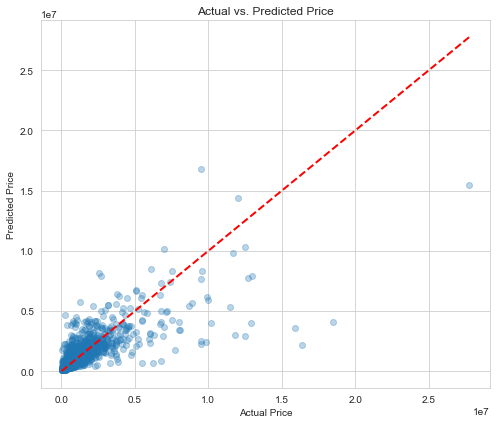

In [153]:
plt.figure(figsize=(7,6))
plt.scatter(y_test_v4, y_test_pred, alpha=0.3)
plt.plot([y_test_v4.min(), y_test_v4.max()], [y_test_v4.min(), y_test_v4.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Price')
plt.tight_layout()
plt.show()

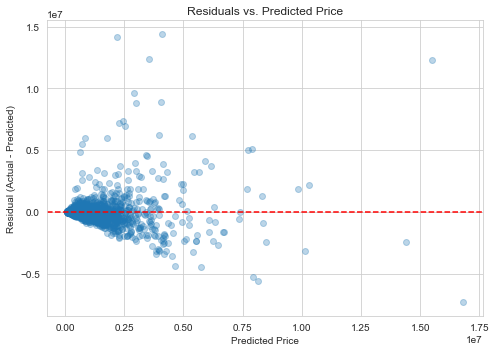

In [154]:
residuals = y_test_v4 - y_test_pred

plt.figure(figsize=(7,5))
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs. Predicted Price')
plt.tight_layout()
plt.show()

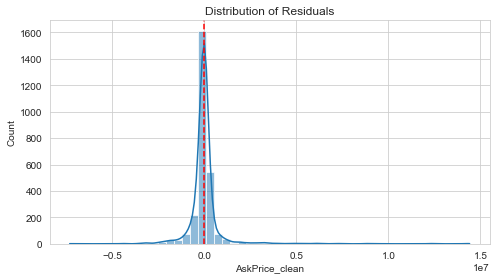

In [155]:
plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

### Residual Analysis

Visual inspection of residuals confirms and extends the overfitting finding above:

- **Actual vs. Predicted:** predictions track closely with actual price at the low end, 
  but increasingly underpredict as actual price rises — visible as a growing gap below 
  the line of perfect prediction for expensive vehicles.
- **Residuals vs. Predicted:** shows a clear funnel (heteroscedastic) pattern — residuals 
  are tightly clustered near zero for cheaper cars but spread widely for higher-priced 
  predictions, indicating the model's error is far less consistent for expensive vehicles.
- **Distribution of residuals:** sharply peaked near zero with a long right tail, showing 
  the model more often **underestimates** price than overestimates it, particularly for 
  high-value cars.

This pattern is consistent with the rare-brand overfitting issue identified earlier: 
luxury and high-price vehicles are underrepresented in the dataset, giving the model too 
few examples to learn reliable pricing patterns for that segment. The model performs well 
for typical, mass-market listings but should not be trusted for high-value vehicle 
pricing without further data.

In [156]:
#***END***

## Insights & Conclusion

### Key Insights from EDA and Data Cleaning

This dataset presented significant real-world data quality challenges that shaped much of 
this project's approach: ~39% of rows were exact duplicates, ~21% of `Year` values were a 
placeholder (9999) rather than genuinely missing, and ~42% of listings lacked a structured 
`Brand` value. Rather than treating these as simple deletions, we recovered substantial 
signal from the unstructured `AdditionInfo` field — reducing missing `Brand` by ~6,000 
rows and missing `FuelType` by ~2,180 rows through text mining. Missingness in `Year`/`Age` 
was also shown to be non-random (Missing Not At Random), overlapping strongly with other 
missing fields, informing the decision to drop rather than impute these rows.

### Modeling Approach and Results

We progressed from a Linear Regression baseline (R² = 0.358) through several rounds of 
model comparison, hyperparameter tuning, and feature engineering, reaching a final Random 
Forest model with R² = 0.594 (RMSE = ₹966,567) — a ~66% relative improvement in R² over 
the baseline, and a ~21% improvement over the initial untuned Random Forest.

Notably, one promising-looking improvement (R² = 0.647) was identified as misleading upon 
investigation: a text-mined `engine_size` feature was 70% imputed with a median value due 
to sparse mentions in the source text, causing the model to partly learn "listing 
completeness" rather than genuine engine size signal. This was caught via feature 
importance analysis and corrected by removing the feature, prioritizing a trustworthy 
result over an inflated one.

### Model Limitations

- **Overfitting:** Train R² (0.757) notably exceeds test R² (0.594), driven partly by the 
  model's capacity (`max_depth=30`, 300 trees) to memorize rare cases — most visibly, 
  brands like Lamborghini and Bentley with only a single listing each in the dataset.
- **Heteroscedastic errors:** Residual analysis showed the model performs well on 
  typical, mass-market vehicles but underpredicts high-value/luxury cars with 
  substantially larger and less consistent error — a direct consequence of limited 
  representation of expensive vehicles in the training data.
- **Missing structural information:** The dataset lacks variant/trim-level detail, 
  service history, and accident records — information that meaningfully drives real-world 
  used car pricing but was not available to recover, even through text mining.

### What We'd Improve With More Time

- Reduce `max_depth` or increase `min_samples_leaf` to address the overfitting identified 
  in Error Analysis, likely trading a small amount of training accuracy for better 
  generalization
- Further mine `AdditionInfo` for additional signal (e.g. more granular condition or 
  feature language), while being more cautious about imputation strategies after the 
  `engine_size` lesson learned here
- Consider a separate, specialized model or stratified approach for the luxury/high-price 
  segment, given how differently the current model performs across the price range
- With more data, particularly more examples of rare/luxury brands, the model would likely 
  generalize better to the segment it currently struggles with most

### Closing Thought

This project's central question was not just "how accurately can we predict price?" but 
"how much of that accuracy is real?" The answer, after verification, correction, and honest 
reporting throughout: a genuine, defensible R² of 0.594 — achieved through rigorous 
cleaning of a messy real-world dataset, careful feature engineering, and a willingness to 
question and correct our own results rather than accept them at face value.